In [22]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np

supp_path = DATA_DIR / "supplementary_data.csv"
supp = pd.read_csv(supp_path)

# Load all input/output weeks
input_dfs = []
output_dfs = []

for week in range(1, 19):
    week_str = f"w{week:02d}"
    input_path = DATA_DIR / "train" / f"input_2023_{week_str}.csv"
    output_path = DATA_DIR / "train" / f"output_2023_{week_str}.csv"
    
    df_in_week = pd.read_csv(input_path)
    df_out_week = pd.read_csv(output_path)
    
    input_dfs.append(df_in_week)
    output_dfs.append(df_out_week)

# Combine all weeks
df_in = pd.concat(input_dfs, ignore_index=True)
df_out = pd.concat(output_dfs, ignore_index=True)



nfl = nfl.import_team_desc()

/var/folders/vx/rnjy46jd0zg50vm2jz6g_fch0000gn/T/ipykernel_18397/2092387106.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  supp = pd.read_csv(supp_path)


In [ ]:
from pathlib import Path

# Set DATA_DIR to the folder containing the Kaggle competition data.
# Download from https://www.kaggle.com/competitions/nfl-big-data-bowl-2025/data
DATA_DIR = Path("data")


In [23]:
# Identify targeted receiver per play
target_ids = (
    df_in[df_in["player_role"] == "Targeted Receiver"]
    [["game_id", "play_id", "nfl_id"]]
    .drop_duplicates()
    .rename(columns={"nfl_id": "target_nfl_id"})
)


df_in  = df_in.merge(target_ids, on=["game_id","play_id"], how="left")
df_out = df_out.merge(target_ids, on=["game_id","play_id"], how="left")

df_in["is_target"]  = df_in["nfl_id"] == df_in["target_nfl_id"]
df_out["is_target"] = df_out["nfl_id"] == df_out["target_nfl_id"]

# mark source of each frame
df_in["phase"] = "pre_throw"
df_out["phase"] = "post_throw"

# combine
df_all = pd.concat([df_in, df_out], ignore_index=True)

# sort frames so each play is in correct order
df_all = df_all.sort_values(["game_id", "play_id", "nfl_id", "phase", "frame_id"])

# Extract target receiver frames (only frames where player is the target)
target_positions = df_all[df_all["is_target"]][
    ["game_id","play_id","frame_id","x","y"]
].rename(columns={"x":"target_x","y":"target_y"})

# Merge onto full tracking table
df_all = df_all.merge(
    target_positions,
    on=["game_id","play_id","frame_id"],
    how="left"
)

# Build a lookup from pre-throw data: who is this player on this play?
player_lookup = (
    df_in[["game_id", "play_id", "nfl_id", "player_side", "player_role"]]
    .drop_duplicates()
)

# Merge onto the full tracking table so post-throw frames get tagged too
df_all = df_all.drop(columns=["player_side", "player_role"], errors="ignore").merge(
    player_lookup,
    on=["game_id", "play_id", "nfl_id"],
    how="left"
)

# Step 1: dx, dy
df_all["dx"] = df_all["target_x"] - df_all["x"]
df_all["dy"] = df_all["target_y"] - df_all["y"]

# Step 2: angle to target (radians)
df_all["angle_to_target"] = np.arctan2(df_all["dy"], df_all["dx"])

# Step 3: defender movement angle (convert degrees → radians)
df_all["movement_angle"] = np.deg2rad(df_all["dir"])

# Step 4: raw angular difference
df_all["angle_diff_raw"] = np.abs(df_all["movement_angle"] - df_all["angle_to_target"])

# Step 5: wrap to [0, π]
df_all["angle_diff"] = np.minimum(df_all["angle_diff_raw"], 2*np.pi - df_all["angle_diff_raw"])

df_all = df_all.sort_values(["game_id","play_id","nfl_id","phase","frame_id"])

# Compute actual delta movement from x/y for each player
df_all["x_prev"] = df_all.groupby(["game_id","play_id","nfl_id"])["x"].shift(1)
df_all["y_prev"] = df_all.groupby(["game_id","play_id","nfl_id"])["y"].shift(1)

df_all["dx_actual"] = df_all["x"] - df_all["x_prev"]
df_all["dy_actual"] = df_all["y"] - df_all["y_prev"]

# True movement direction from position changes
df_all["angle_actual"] = np.arctan2(df_all["dy_actual"], df_all["dx_actual"])

# Convert provided movement_angle into radians
df_all["movement_angle_rad"] = np.deg2rad(df_all["dir"])

# Angle difference between true vs provided
df_all["movement_angle_error"] = np.abs(df_all["movement_angle_rad"] - df_all["angle_actual"])
df_all["movement_angle_error"] = np.where(
    df_all["movement_angle_error"] > np.pi,
    2*np.pi - df_all["movement_angle_error"],
    df_all["movement_angle_error"]
)


# Separation from target
df_all["separation"] = np.sqrt(
    (df_all["x"] - df_all["target_x"])**2 +
    (df_all["y"] - df_all["target_y"])**2
)

# Movement vector components
df_all["mvx"] = df_all["s"] * np.cos(df_all["movement_angle_rad"])
df_all["mvy"] = df_all["s"] * np.sin(df_all["movement_angle_rad"])

# Unit vector toward target (avoid division by zero)
df_all["ux"] = np.where(df_all["separation"] > 0, df_all["dx"] / df_all["separation"], 0)
df_all["uy"] = np.where(df_all["separation"] > 0, df_all["dy"] / df_all["separation"], 0)

# Projected closing speed
df_all["closing_speed"] = df_all["mvx"] * df_all["ux"] + df_all["mvy"] * df_all["uy"]

print(df_all[["mvx","mvy","ux","uy","closing_speed"]].head(10))
print(df_all["closing_speed"].describe())

# Angle difference wrapped to [0, π]
df_all["angle_diff"] = np.abs(df_all["angle_diff_raw"])
df_all["angle_diff"] = np.where(df_all["angle_diff"] > np.pi,
                                2*np.pi - df_all["angle_diff"],
                                df_all["angle_diff"])

valid_results = ["C", "I", "IN"]

# attach play info
df_all = df_all.merge(
    supp[["game_id","play_id","pass_result"]],
    on=["game_id","play_id"],
    how="left"
)

# filter to only passing plays where ball was thrown
df_pass = df_all[df_all["pass_result"].isin(valid_results)].copy()
df_flight = df_pass[df_pass["phase"] == "post_throw"].copy()
df_def = df_flight[df_flight["player_side"] == "Defense"].copy()

# Step 1: Get the throw frame (last pre_throw frame) for each play
throw_frames = (
    df_all[df_all["phase"] == "pre_throw"]
    .groupby(["game_id", "play_id"])["frame_id"]
    .max()
    .reset_index()
    .rename(columns={"frame_id": "throw_frame"})
)

# Step 2: Merge throw frame info back into df_all
df_throw = df_all.merge(
    throw_frames, on=["game_id", "play_id"], how="inner"
)

# Step 3: Keep only the rows that correspond to the throw moment
df_throw = df_throw[df_throw["frame_id"] == df_throw["throw_frame"]]

# Step 4: Keep only defenders
df_throw = df_throw[df_throw["player_side"] == "Defense"]

# Step 5: Attach the target variable y
df_throw["y"] = (df_throw["pass_result"] == "C").astype(int)

df_throw = df_throw.merge(
    supp, 
    on=["game_id", "play_id"], 
    how="left", 
    suffixes=('', '_supp')
).drop_duplicates(subset=["game_id", "play_id"])

# Filter to only valid passing plays
df_model = df_throw[df_throw["pass_result"].isin(["C", "IN", "I"])].copy()

# Binary target: 1 if completion, 0 otherwise
df_model["target"] = (df_model["pass_result"] == "C").astype(int)


# Convert height string "6-1" → total inches
def height_to_inches(height_str):
    try:
        feet, inches = map(int, height_str.split('-'))
        return feet * 12 + inches
    except:
        return np.nan  # handle missing or malformed values

df_model["player_height"] = df_model["player_height"].apply(height_to_inches)



        mvx      mvy        ux        uy  closing_speed
0  0.000000  0.00000  0.701549 -0.712621       0.000000
1  0.000000  0.00000  0.200850 -0.979622       0.000000
2  0.000000  0.00000  0.713740 -0.700411       0.000000
3  0.000000  0.00000  0.200850 -0.979622       0.000000
4  0.000000  0.00000  0.724009 -0.689791       0.000000
5  0.000000  0.00000  0.202533 -0.979275       0.000000
6  0.000000 -0.00000  0.732375 -0.680902       0.000000
7  0.000000 -0.00000  0.204326 -0.978903       0.000000
8  0.001895 -0.05997  0.738656 -0.674083       0.041825
9  0.001895 -0.05997  0.207170 -0.978305       0.059062
count    6.830128e+06
mean    -1.626460e-02
std      2.385321e+00
min     -1.002218e+01
25%     -9.826916e-01
50%     -0.000000e+00
75%      9.513036e-01
max      9.934937e+00
Name: closing_speed, dtype: float64


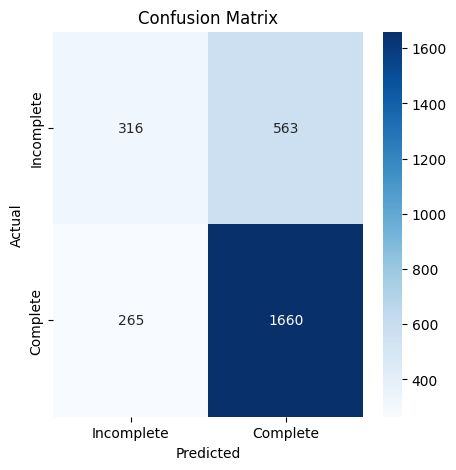

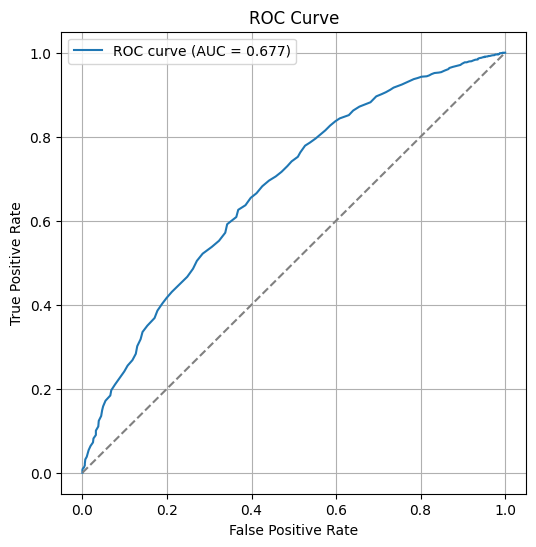

Random Forest Classification Summary:
Accuracy : 0.7047
Precision: 0.7467
Recall   : 0.8623
ROC AUC  : 0.6773
RMSE     : 0.4430
R^2      : 0.0880


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, mean_squared_error
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# -----------------------------
# 1. Feature selection
# -----------------------------
features = [
    # Defender movement / coverage
    "closing_speed", "mvx", "mvy", "ux", "uy",
    "dx", "dy", "angle_to_target", "angle_diff", "separation",
    
    # Player traits
    "player_height", "player_weight",
    
    # Play context / situational
    "yards_to_go", "absolute_yardline_number",  "dropback_distance", "defenders_in_the_box", "team_coverage_type", 
    "offense_formation", "receiver_alignment", "route_of_targeted_receiver",
    "play_action", "dropback_type", "pass_location_type", 'play_direction'
]

# Ensure categorical variables are treated properly
categoricals = [
    "play_direction", "offense_formation", "receiver_alignment",
    "route_of_targeted_receiver", "play_action", "dropback_type",
    "pass_location_type", "team_coverage_type"
]


X = df_model[features].copy()
y = df_model["target"].copy()

# One-hot encode categoricals
X = pd.get_dummies(X, columns=categoricals, drop_first=True)

# -----------------------------
# 2. Play-level train/test split
# -----------------------------
unique_plays = df_model["play_id"].unique()
train_plays, test_plays = train_test_split(unique_plays, test_size=0.2, random_state=42)

train_mask = df_model["play_id"].isin(train_plays)
test_mask  = df_model["play_id"].isin(test_plays)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# -----------------------------
# 3. Train Random Forest Classifier
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# After model.predict_proba(...)
proba = rf.predict_proba(X_test)[:, 1]

# Replace the old arbitrary threshold with a football-driven one.
# Example: use league-average completion probability as the threshold.
# (You already computed class proportions earlier.)
league_base_rate = y_train.mean()        # ~0.69 in your data

threshold = league_base_rate - 0.1           # <-- update this line

pred = (proba >= threshold).astype(int)


# -----------------------------
# 4. Predictions & metrics
# -----------------------------
y_pred = pred

y_prob = rf.predict_proba(X_test)[:,1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)
rmse      = np.sqrt(mean_squared_error(y_test, y_prob))

# Pseudo R²
y_mean = np.mean(y_test)
ss_tot = np.sum((y_test - y_mean)**2)
ss_res = np.sum((y_test - y_prob)**2)
r2 = 1 - ss_res/ss_tot

# -----------------------------
# 5. Confusion matrix visual
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
labels = ["Incomplete", "Complete"]

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 6. ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 7. Summary output
# -----------------------------
print("Random Forest Classification Summary:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R^2      : {r2:.4f}")


Class counts:
target
1    9738
0    4369
Name: count, dtype: int64

Class percentages:
target
1    69.02956
0    30.97044
Name: proportion, dtype: float64


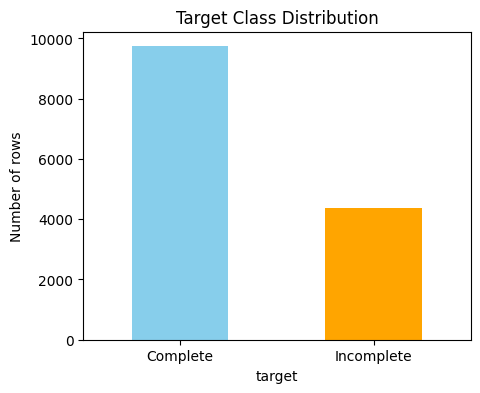

In [25]:
# Count of completions vs incompletions
class_counts = df_model["target"].value_counts()
class_percent = df_model["target"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_percent)

# Optional: visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
class_counts.plot(kind='bar', color=["skyblue", "orange"])
plt.xticks([0,1], ["Complete", "Incomplete"], rotation=0)
plt.ylabel("Number of rows")
plt.title("Target Class Distribution")
plt.show()


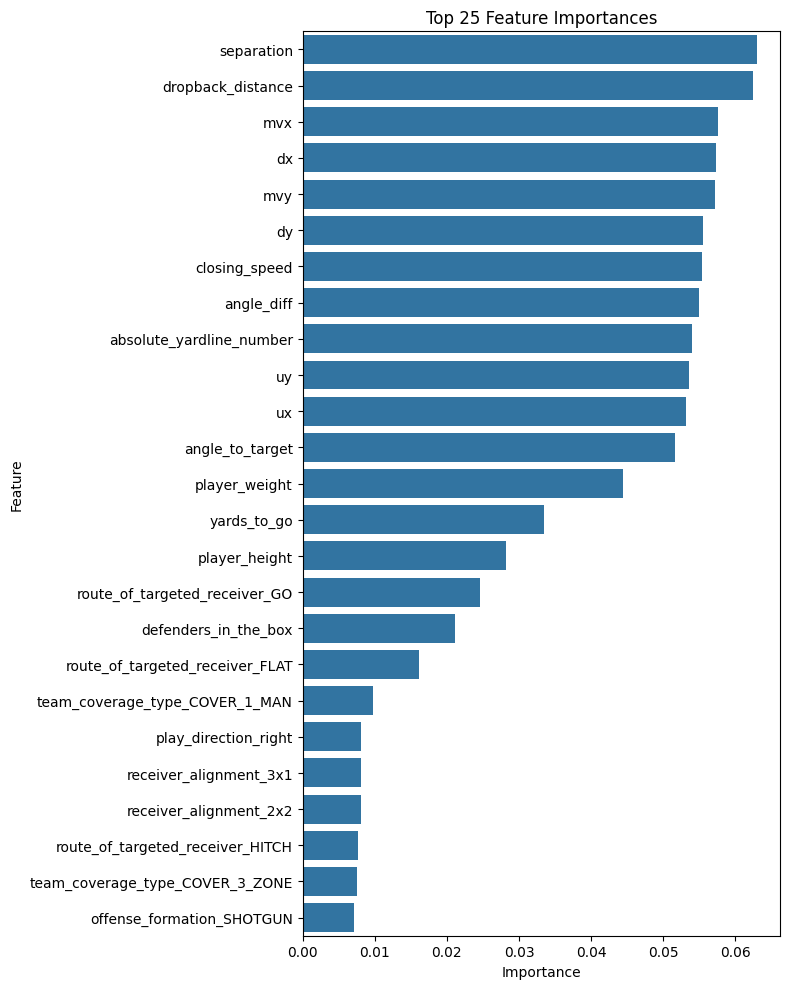

In [26]:
import shap
# -----------------------------
# Feature Importance Visual
# -----------------------------
importances = rf.feature_importances_
feature_names = X_train.columns

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(data=fi.head(25), y="feature", x="importance")
plt.title("Top 25 Feature Importances")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [27]:
df_all_processed = df_all.copy()

In [28]:
required_features = [
    "yards_to_go", "dropback_distance", "defenders_in_the_box",
    "team_coverage_type", "offense_formation", "receiver_alignment",
    "route_of_targeted_receiver", "play_action", "dropback_type",
    "pass_location_type"
]


In [29]:
import numpy as np
import pandas as pd

# -----------------------------
# 1. Make a preprocessed copy


# Merge supplementary/play-level features once
df_all_processed = df_all_processed.merge(
    supp[['game_id', 'play_id'] + required_features],
    on=['game_id','play_id'],
    how='left'
)

# Ensure player_name exists for all players
player_names = df_in[['game_id','play_id','nfl_id','player_name']].drop_duplicates()
df_all_processed = df_all_processed.drop(columns=['player_name'], errors='ignore').merge(
    player_names,
    on=['game_id','play_id','nfl_id'],
    how='left'
)

# Convert height to inches once
def height_to_inches(height_str):
    try:
        feet, inches = map(int, str(height_str).split('-'))
        return feet * 12 + inches
    except:
        return np.nan

df_all_processed["player_height"] = df_all_processed["player_height"].apply(height_to_inches)
median_height = df_model["player_height"].median()
df_all_processed["player_height"] = df_all_processed["player_height"].fillna(median_height)

# -----------------------------
# 2. Pick a random play
# -----------------------------
plays_with_target = df_all_processed[df_all_processed['is_target'] == True].dropna(subset=required_features)
random_play = plays_with_target.sample(n=1, random_state=None)  # different each time
game_to_predict = random_play.iloc[0]['game_id']
play_to_predict = random_play.iloc[0]['play_id']

print(f"Random play selected: game_id={game_to_predict}, play_id={play_to_predict}")

# Extract play
play_df = df_all_processed[(df_all_processed['game_id'] == game_to_predict) &
                           (df_all_processed['play_id'] == play_to_predict)].copy()

# -----------------------------
# 3. Build model input
# -----------------------------
X_play = play_df[features].copy()
X_play = pd.get_dummies(X_play, columns=categoricals, drop_first=True)
X_play = X_play.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------
# 4. Make predictions
# -----------------------------
play_proba = rf.predict_proba(X_play)[:, 1]
play_pred  = (play_proba >= threshold).astype(int)

play_df['pred_prob'] = play_proba
play_df['pred_target'] = play_pred

# -----------------------------
# 5. Identify closest defender to target
# -----------------------------
receiver_pos = play_df[play_df['is_target']][['x','y']].iloc[0]
defenders = play_df[play_df['player_side'] == 'Defense'].copy()

# Compute distance to target receiver
defenders['dist_to_target'] = np.sqrt(
    (defenders['x'] - receiver_pos['x'])**2 +
    (defenders['y'] - receiver_pos['y'])**2
)

# Closest defender
closest_defender = defenders.loc[defenders['dist_to_target'].idxmin()]

closest_defender_info = closest_defender[[
    'player_name', 'nfl_id', 'pred_prob', 'pred_target', 'dist_to_target'
]].rename({
    'pred_prob': 'predicted_probability',
    'pred_target': 'predicted_completion'
})

closest_defender_info


Random play selected: game_id=2023110503, play_id=626


player_name              Starling Thomas V
nfl_id                               56353
predicted_probability                0.525
predicted_completion                     0
dist_to_target                    1.037401
Name: 3674416, dtype: object

Animating play: game_id=2023112700, play_id=2541
Pass result: IN (Incomplete)
Offensive team (MIN): #4F2683
Defensive team (CHI): #0B162A


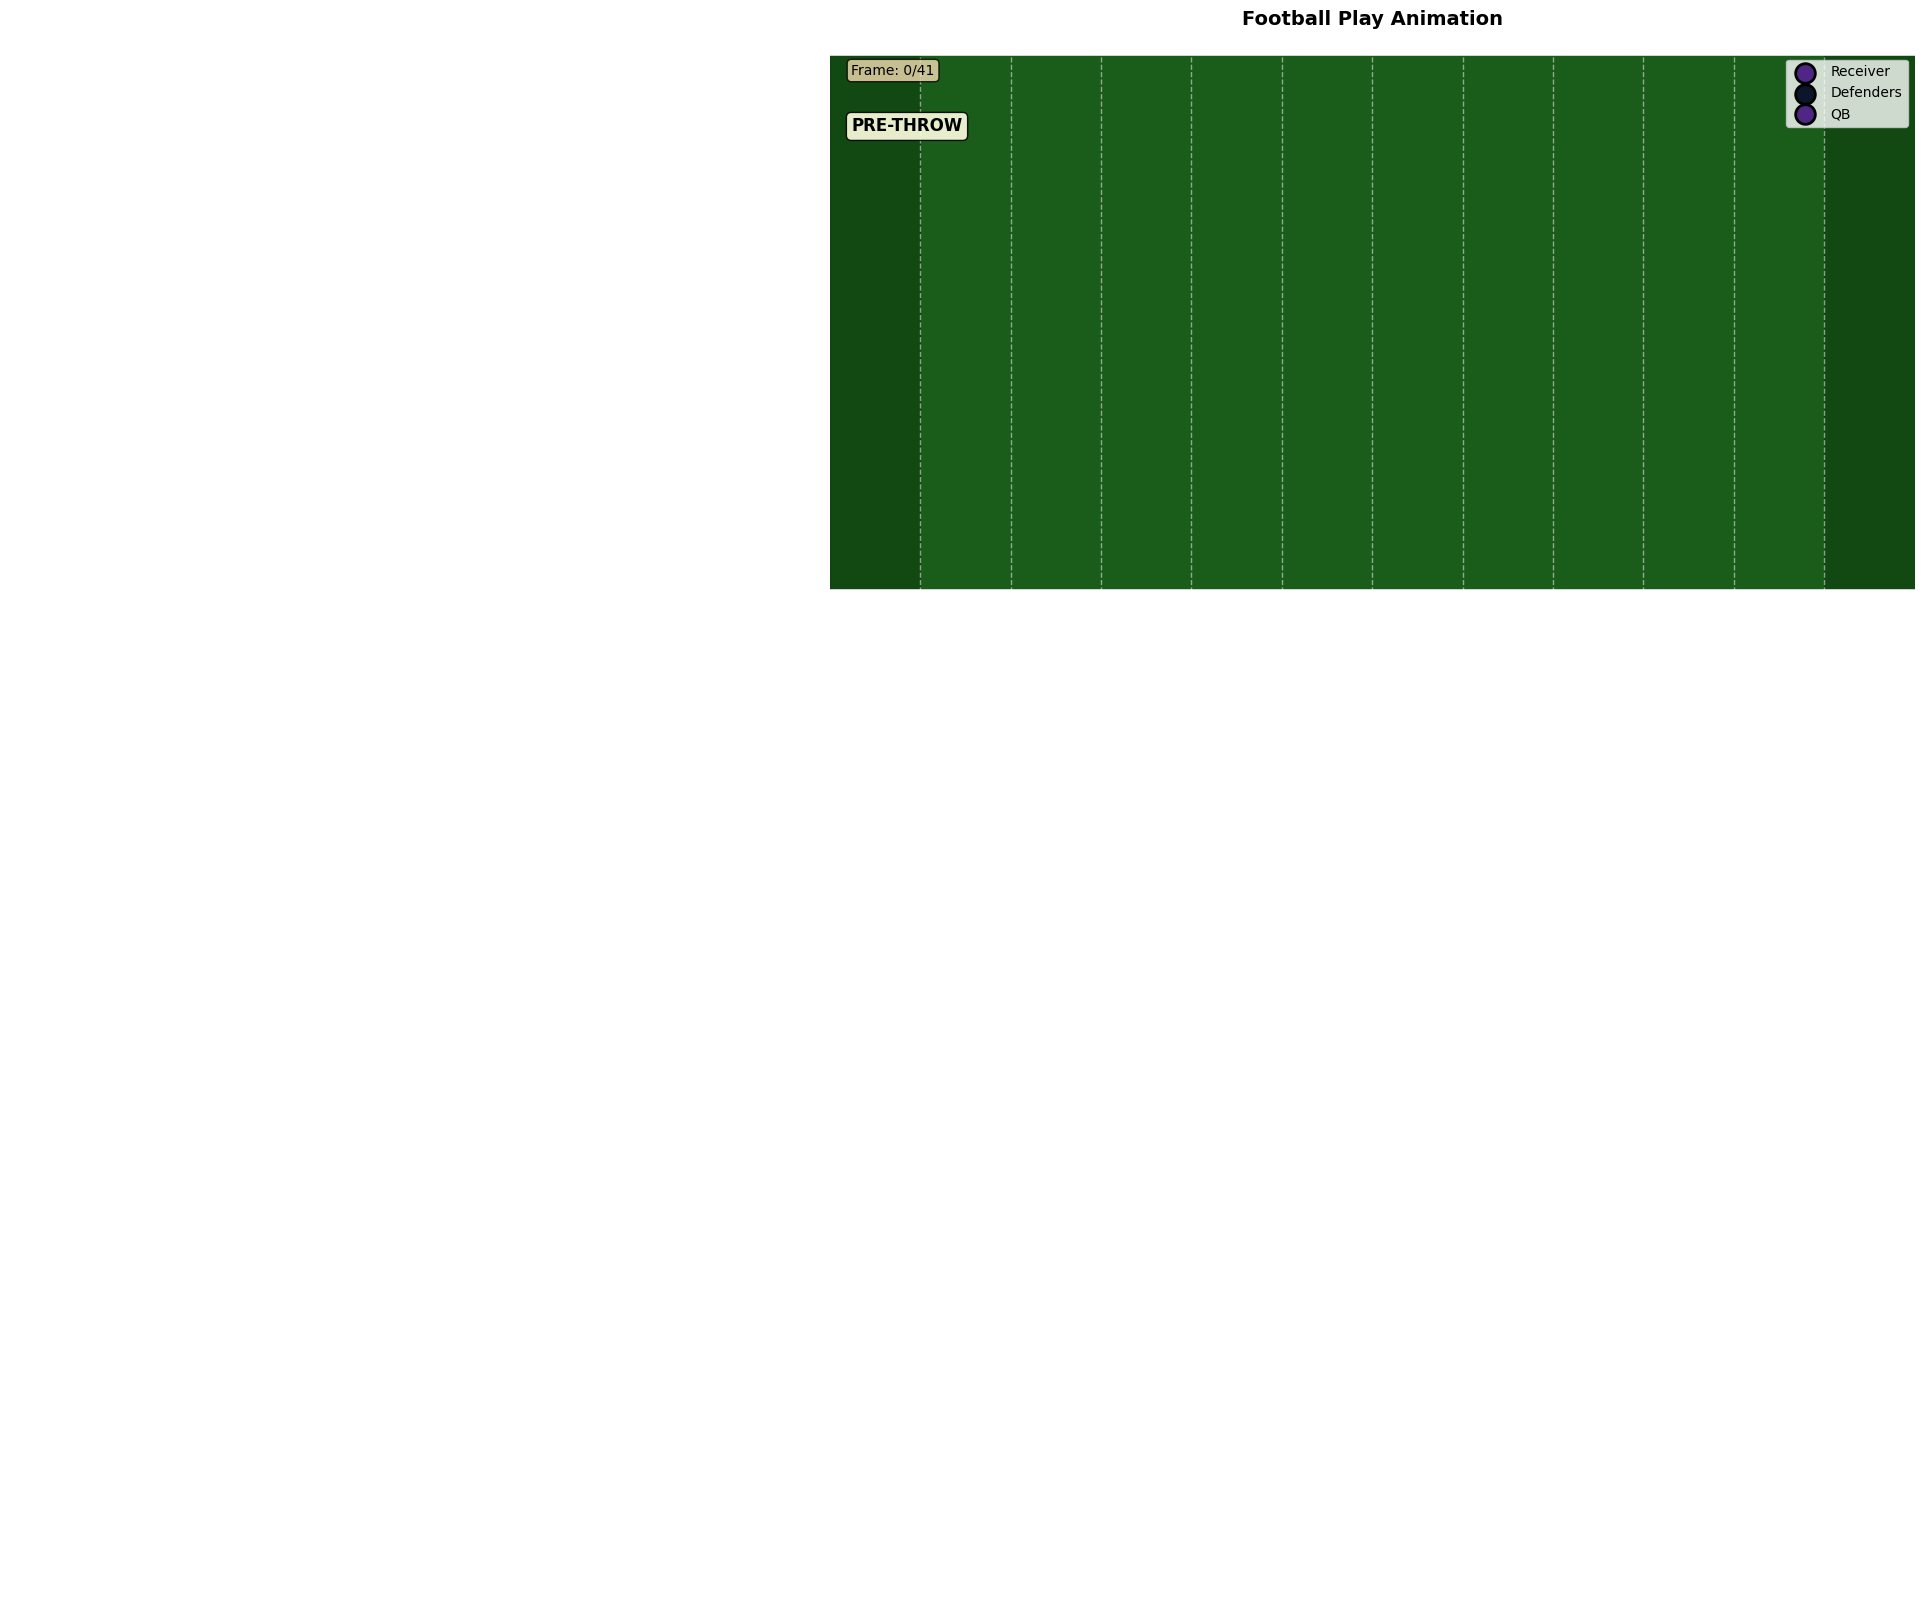

In [30]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import pandas as pd

# Run the prediction code
game_id = 2023112700
play_id = 2541

single_play = df_all[(df_all['game_id'] == game_id) & (df_all['play_id'] == play_id)].copy()
game_info = supp[(supp['game_id'] == game_id) & (supp['play_id'] == play_id)]

# Merge supplementary features
required_features = [
    "yards_to_go", "dropback_distance", "defenders_in_the_box",
    "team_coverage_type", "offense_formation", "receiver_alignment",
    "route_of_targeted_receiver", "play_action", "dropback_type",
    "pass_location_type"
]

single_play = single_play.merge(
    supp[['game_id', 'play_id'] + required_features],
    on=['game_id','play_id'],
    how='left'
)

# Convert height to inches
def height_to_inches(height_str):
    try:
        feet, inches = map(int, str(height_str).split('-'))
        return feet * 12 + inches
    except:
        return np.nan

single_play["player_height"] = single_play["player_height"].apply(height_to_inches)
median_height = 73  # Use a reasonable default (around 6'1")
single_play["player_height"] = single_play["player_height"].fillna(median_height)

# Build model input
features = [
    "closing_speed", "mvx", "mvy", "ux", "uy",
    "dx", "dy", "angle_to_target", "angle_diff", "separation",
    "player_height", "player_weight",
    "yards_to_go", "absolute_yardline_number",  "dropback_distance", "defenders_in_the_box", "team_coverage_type", 
    "offense_formation", "receiver_alignment", "route_of_targeted_receiver",
    "play_action", "dropback_type", "pass_location_type", 'play_direction'
]

categoricals = [
    "play_direction", "offense_formation", "receiver_alignment",
    "route_of_targeted_receiver", "play_action", "dropback_type",
    "pass_location_type", "team_coverage_type"
]

X_play = single_play[features].copy()
X_play = pd.get_dummies(X_play, columns=categoricals, drop_first=True)
X_play = X_play.reindex(columns=X_train.columns, fill_value=0)

# Make predictions
play_proba = rf.predict_proba(X_play)[:, 1]
play_pred = (play_proba >= threshold).astype(int)

play_df = single_play.copy()
play_df['pred_prob'] = play_proba
play_df['pred_target'] = play_pred

print(f"Animating play: game_id={game_id}, play_id={play_id}")

# Get the data from df_all with continuous frames
play_animation_df = df_all[(df_all['game_id'] == game_id) & (df_all['play_id'] == play_id)].copy()

# Fill in missing player names from df_in (which has player_name data)
player_names_from_input = df_in[['game_id', 'play_id', 'nfl_id', 'player_name']].drop_duplicates()
play_animation_df = play_animation_df.merge(player_names_from_input, on=['game_id', 'play_id', 'nfl_id'], how='left', suffixes=('', '_input'))
play_animation_df['player_name'] = play_animation_df['player_name'].fillna(play_animation_df['player_name_input'])
play_animation_df = play_animation_df.drop(columns=['player_name_input'], errors='ignore')

# Get the target receiver's nfl_id for this play
target_nfl_id = play_animation_df['target_nfl_id'].iloc[0]

# Create continuous frame numbering across pre/post throw
play_animation_df = play_animation_df.sort_values(['phase', 'frame_id']).copy()
phase_map = {'pre_throw': 0, 'post_throw': 1}
play_animation_df['phase_order'] = play_animation_df['phase'].map(phase_map)

# Get max frames for each phase
max_pre = play_animation_df[play_animation_df['phase'] == 'pre_throw']['frame_id'].max()
max_post = play_animation_df[play_animation_df['phase'] == 'post_throw']['frame_id'].max()

# Create continuous frame_id: pre_throw frames stay 0-N, post_throw become N+1 onwards
play_animation_df['continuous_frame'] = play_animation_df.apply(
    lambda row: row['frame_id'] if row['phase'] == 'pre_throw' else max_pre + row['frame_id'],
    axis=1
)

# Merge predictions from play_df (based on nfl_id and phase/frame_id)
play_df_pred = play_df[['nfl_id', 'pred_prob']].drop_duplicates()
play_animation_df = play_animation_df.merge(play_df_pred, on=['nfl_id'], how='left')

# Filter to target receiver
receiver_df = play_animation_df[(play_animation_df['nfl_id'] == target_nfl_id)].dropna(subset=['frame_id'])
if receiver_df.empty:
    raise ValueError("No target receiver found in this play.")

num_frames_output = int(play_animation_df['continuous_frame'].max() + 1)

defender_df = play_animation_df[play_animation_df['player_side'] == 'Defense'].dropna(subset=['frame_id'])
offense_df = play_animation_df[play_animation_df['player_side'] == 'Offense'].dropna(subset=['frame_id'])

# Get pass result and team colors
pass_result = play_animation_df['pass_result'].iloc[0]
is_complete = pass_result == 'C'

# Get game info to find teams
game_info_row = supp[(supp['game_id'] == game_id) & (supp['play_id'] == play_id)]
if not game_info_row.empty:
    possession_team = game_info_row['possession_team'].iloc[0]
    defensive_team = game_info_row['defensive_team'].iloc[0]
else:
    possession_team = None
    defensive_team = None

# Get offensive team color
if possession_team:
    offense_color_row = nfl[nfl['team_abbr'] == possession_team]
    if not offense_color_row.empty:
        offense_color = offense_color_row['team_color'].iloc[0]
    else:
        offense_color = 'blue'
else:
    offense_color = 'blue'

# Get defensive team color
if defensive_team:
    defense_color_row = nfl[nfl['team_abbr'] == defensive_team]
    if not defense_color_row.empty:
        defense_color = defense_color_row['team_color'].iloc[0]
    else:
        defense_color = 'red'
else:
    defense_color = 'red'

# Receiver color only changes in post-throw phase
receiver_pre_throw_color = offense_color
receiver_post_throw_color = 'green' if is_complete else 'red'

print(f"Pass result: {pass_result} ({'Complete' if is_complete else 'Incomplete'})")
print(f"Offensive team ({possession_team}): {offense_color}")
print(f"Defensive team ({defensive_team}): {defense_color}")

# Create a color map for defender threat level (pred_prob)
def get_threat_color(pred_prob):
    """
    Convert prediction probability to color
    Low prob (high threat) = red/warm colors
    High prob (low threat) = blue/cool colors
    """
    if pd.isna(pred_prob):
        return 'gray'
    # Clamp between 0 and 1
    prob = max(0, min(1, pred_prob))
    # Invert: lower prob = higher threat = warmer color
    threat_level = 1 - prob
    
    if threat_level < 0.2:  # Low threat
        return '#0000FF'  # Blue
    elif threat_level < 0.4:  # Low-medium threat
        return '#00FF00'  # Green
    elif threat_level < 0.6:  # Medium threat
        return '#FFFF00'  # Yellow
    elif threat_level < 0.8:  # Medium-high threat
        return '#FF7700'  # Orange
    else:  # High threat
        return '#FF0000'  # Red

# Get high-impact defenders from the predictions
high_impact_defenders = play_df[play_df['player_side'] == 'Defense']['nfl_id'].unique()
high_impact_defenders = set(high_impact_defenders)

# Calculate frame threshold (25% of total frames)
frame_threshold = int(num_frames_output * 0.25)

# ----------------------------------------------------------
# FIELD SETUP
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(-10, 110)
ax.set_ylim(0, 53.3)
ax.set_title("Football Play Animation", pad=20, fontsize=14, weight='bold')
ax.set_facecolor('#1a5c1a')  # Dark green field

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# End zones
left_endzone = plt.Rectangle((-10, 0), 10, 53.3, color='#0d3d0d', alpha=0.6)
right_endzone = plt.Rectangle((100, 0), 10, 53.3, color='#0d3d0d', alpha=0.6)
ax.add_patch(left_endzone)
ax.add_patch(right_endzone)

# Yard lines (white)
for yd in range(0, 101, 10):
    ax.axvline(yd, linestyle='--', alpha=0.5, color='white', linewidth=1)

# Field boundaries (white)
ax.axhline(0, linewidth=4, color='white')
ax.axhline(53.3, linewidth=4, color='white')

# Yard labels (white)
yard_labels = [0, 10, 20, 30, 40, 50, 40, 30, 20, 10, 0]
for i, yd in enumerate(range(0, 101, 10)):
    ax.text(yd, 53.3, str(yard_labels[i]),
            ha='center', va='bottom', fontsize=8, alpha=0.9, color='white', weight='bold')

# ----------------------------------------------------------
# ANIMATION ELEMENTS
# ----------------------------------------------------------

receiver_scat = ax.scatter([], [], c=receiver_pre_throw_color, s=200, edgecolors='black', linewidth=2, label='Receiver')
defender_scat = ax.scatter([], [], c=defense_color, s=200, edgecolors='black', linewidth=2, label='Defenders')
qb_scat = ax.scatter([], [], c=offense_color, s=200, edgecolors='black', linewidth=2, label='QB')

receiver_text = ax.text(0, 0, '', color='white', ha='center', va='bottom', fontsize=8, weight='bold')
qb_text = ax.text(0, 0, 'Q', color='white', ha='center', va='center', fontsize=10, weight='bold')

frame_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                     va='top', ha='left', fontsize=10, 
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
throw_text = ax.text(0.02, 0.88, '', transform=ax.transAxes, 
                     va='top', ha='left', fontsize=12, weight='bold',
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# Store movement lines and text labels for defenders
movement_lines = []
defender_texts = []

# Find the transition frame (last pre_throw frame)
max_pre_frame = play_animation_df[play_animation_df['phase'] == 'pre_throw']['continuous_frame'].max()
throw_continuous_frame = max_pre_frame

ax.legend(loc='upper right', fontsize=10)

def update(frame):
    global movement_lines, defender_texts
    
    # Remove old movement lines and texts
    for line in movement_lines:
        line.remove()
    for text in defender_texts:
        text.remove()
    movement_lines.clear()
    defender_texts.clear()
    
    # Determine which defenders to show
    if frame >= frame_threshold:
        active_defenders = high_impact_defenders
    else:
        active_defenders = defender_df['nfl_id'].unique()
    
    # Target receiver
    rx = receiver_df.loc[receiver_df['continuous_frame'] == frame, 'x'].dropna().values
    ry = receiver_df.loc[receiver_df['continuous_frame'] == frame, 'y'].dropna().values
    receiver_scat.set_offsets(np.c_[rx, ry] if rx.size else np.zeros((0, 2)))
    
    # Receiver name
    if rx.size > 0:
        receiver_name = receiver_df.iloc[0]['player_name']
        receiver_text.set_position((rx[0], ry[0] + 2))
        receiver_text.set_text(receiver_name)
    else:
        receiver_text.set_text('')
    
    # Change receiver color based on phase
    if frame >= throw_continuous_frame:
        receiver_scat.set_color(receiver_post_throw_color)
    else:
        receiver_scat.set_color(receiver_pre_throw_color)
    
    # Defenders (filtered and deduplicated)
    defender_frame = defender_df[(defender_df['continuous_frame'] == frame) & 
                                  (defender_df['nfl_id'].isin(active_defenders))]
    defender_unique = defender_frame[['nfl_id', 'x', 'y', 'player_name']].drop_duplicates(subset=['nfl_id', 'x', 'y'])
    
    dx = defender_unique['x'].dropna().values
    dy = defender_unique['y'].dropna().values
    defender_scat.set_offsets(np.c_[dx, dy] if dx.size else np.zeros((0, 2)))
    
    # Add defender names
    for _, def_row in defender_unique.iterrows():
        def_text = ax.text(def_row['x'], def_row['y'] - 2, def_row['player_name'], 
                          color='white', ha='center', va='top', fontsize=7, weight='bold')
        defender_texts.append(def_text)
    
    # Draw movement trails for defenders (history of positions)
    for def_id in active_defenders:
        # Get all positions up to current frame for this defender
        def_history = defender_df[(defender_df['nfl_id'] == def_id) & 
                                  (defender_df['continuous_frame'] <= frame)][['continuous_frame', 'x', 'y']].drop_duplicates(subset=['continuous_frame']).sort_values('continuous_frame')
        
        if len(def_history) > 1:
            # Get the defender's pred_prob for coloring
            def_pred_prob = play_df[play_df['nfl_id'] == def_id]['pred_prob'].iloc[0] if len(play_df[play_df['nfl_id'] == def_id]) > 0 else None
            threat_color = get_threat_color(def_pred_prob)
            
            # Draw line connecting all positions in history
            line, = ax.plot(def_history['x'].values, def_history['y'].values,
                           color=threat_color, linestyle='-', alpha=0.7, linewidth=2, zorder=1)
            movement_lines.append(line)
    
    # QB position
    qb_row = offense_df[(~offense_df['is_target']) & (offense_df['continuous_frame'] == frame)]
    qb_row = qb_row.iloc[:1]
    if not qb_row.empty:
        qb_x = qb_row['x'].values[0]
        qb_y = qb_row['y'].values[0]
        qb_scat.set_offsets(np.array([[qb_x, qb_y]]))
        qb_text.set_position((qb_x, qb_y))
    else:
        qb_scat.set_offsets(np.zeros((0, 2)))
        qb_text.set_position((-100, -100))
    
    # Update frame counter
    frame_text.set_text(f'Frame: {frame}/{num_frames_output - 1}')
    
    # Show throw phase indicator
    if frame >= throw_continuous_frame:
        throw_text.set_text('POST-THROW')
    else:
        throw_text.set_text('PRE-THROW')
    
    return receiver_scat, defender_scat, qb_scat, qb_text, receiver_text, frame_text, throw_text

ani = FuncAnimation(fig, update, frames=range(num_frames_output), 
                   interval=100, blit=False, repeat=True)
HTML(ani.to_jshtml())

In [31]:
game_id=2023112700
play_id=2541
single_play = df_all[(df_all['game_id'] == game_id) & (df_all['play_id'] == play_id)]

single_play

game_info = supp[
    (supp['game_id'] == game_id) &
    (supp['play_id'] == play_id)
]

game_info



,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,team_coverage_type,penalty_yards,pre_penalty_yards_gained,yards_gained,expected_points,expected_points_added,pre_snap_home_team_win_probability,pre_snap_visitor_team_win_probability,home_team_win_probability_added,visitor_team_win_probility_added
9382,2023112700,2023,12,11/27/2023,20:15:00,MIN,CHI,2541,(2:46) (Shotgun) J.Dobbs pass short middle int...,3,...,COVER_3_ZONE,NaN,0,0,0.30541,-2.127451,0.396583,0.603417,-0.046251,0.046251


In [ ]:
single_play